# CodonFM (Encodon): codon-optimizing a real gene, round by round

![CodonFM (Encodon)](https://proto-bio.github.io/proto-assets/images/tool/codonfm/hero.png)

CodonFM / **Encodon** ([Darabi et al., 2025](https://research.nvidia.com/labs/dbr/assets/data/manuscripts/nv-codonfm-preprint.pdf)) is a bidirectional (masked) codon language model. We take a **real gene** (human preproinsulin, natural CDS from NCBI), tour every CodonFM tool, then **iteratively improve** the sequence with a CodonFM-guided *synonymous* codon optimization — one codon per round, re-scoring in context each time (the model is bidirectional, so every swap changes its neighbours' scores). We plot the full **progression** of every metric (CodonFM fitness, CAI, MFE, GC%, U%) across the rounds, and show that CodonFM's learned fitness already **co-varies with CAI and MFE**.

> **License:** Encodon code is Apache-2.0; weights are under the NVIDIA Open Model License. The `nvidia/NV-CodonFM-Encodon-*-v1` HuggingFace repos are public — no token required.

In [1]:
from proto_tools.utils.notebook_docs import (
    display_api_reference,
    display_available_tools,
    display_doc_link,
    display_docs_section,
    display_overview,
)

display_doc_link("codonfm")
display_overview("codonfm")
display_docs_section("codonfm", "Background")

# CodonFM (Encodon)

CodonFM (model name Encodon) is a codon-level masked language model of protein-coding sequences from NVIDIA. Unlike nucleotide- or amino-acid-level models, Encodon tokenizes a coding sequence in-frame at codon resolution (one token per 3 nt), so it directly captures synonymous-codon usage and codon-context signals that are invisible to an amino-acid model. This toolkit exposes four Encodon checkpoints (80M, 600M, 1B, and a codon-frequency-aware-masking 1B variant) for coding-sequence fitness scoring, mutation-effect prediction, embeddings, and differentiable sequence design.

Encodon is a BERT-style Transformer encoder trained with a masked-language-modeling objective over codon tokens ([Darabi et al., 2025](https://research.nvidia.com/labs/dbr/assets/data/manuscripts/nv-codonfm-preprint.pdf)). Each coding sequence is split into in-frame codons, a fraction of codon tokens are masked, and the model predicts the original codon from its full bidirectional context. Because the vocabulary is codons rather than amino acids, the model learns the *language of codon translation* — which synonymous codon is expected in a given context — and not only the encoded protein. The released family spans four checkpoints (80M, 600M, 1B parameters, plus a codon-frequency-aware-masking 1B variant), all reading sequences up to 2048 tokens, i.e. coding sequences up to `(2048 - 2) × 3 = 6138 nt` after the CLS/SEP tokens.

## Available tools

In [2]:
display_available_tools("codonfm")

- **`run_codonfm_embeddings()`** — Extract final-layer CLS embeddings for coding sequences with the CodonFM/Encodon model
- **`run_codonfm_fitness()`** — Score coding-sequence fitness with the upstream CodonFM/Encodon visible-token objective
- **`run_codonfm_gradient()`** — Compute the CodonFM/Encodon masked pseudo-log-likelihood gradient for relaxed coding sequences
- **`run_codonfm_sample()`** — Resample a subset of codons in coding sequences with the CodonFM/Encodon model
- **`run_codonfm_score()`** — Score codon substitutions by ref-vs-alt log-likelihood ratio with the CodonFM/Encodon model

## The design target — human preproinsulin (natural CDS)

The wild-type coding sequence of human insulin (RefSeq NM_000207), fetched from NCBI.

In [3]:
from itertools import product

DEVICE = "cuda"
CHECKPOINT = "encodon_80m"

_BASES = "TCAG"
_AAS = "FFLLSSSSYY**CC*WLLLLPPPPHHQQRRRRIIIMTTTTNNKKSSRRVVVVAAAADDEEGGGG"
STANDARD_GENETIC_CODE = {a + b + c: aa for (a, b, c), aa in zip(product(_BASES, repeat=3), _AAS)}
SYNONYMS = {}
for _c, _aa in STANDARD_GENETIC_CODE.items():
    SYNONYMS.setdefault(_aa, []).append(_c)


def translate(cds):
    return "".join(STANDARD_GENETIC_CODE[cds[i : i + 3]] for i in range(0, len(cds), 3))


NATURAL_CDS = "ATGGCCCTGTGGATGCGCCTCCTGCCCCTGCTGGCGCTGCTGGCCCTCTGGGGACCTGACCCAGCCGCAGCCTTTGTGAACCAACACCTGTGCGGCTCACACCTGGTGGAAGCTCTCTACCTAGTGTGCGGGGAACGAGGCTTCTTCTACACACCCAAGACCCGCCGGGAGGCAGAGGACCTGCAGGTGGGGCAGGTGGAGCTGGGCGGGGGCCCTGGTGCAGGCAGCCTGCAGCCCTTGGCCCTGGAGGGGTCCCTGCAGAAGCGTGGCATTGTGGAACAATGCTGTACCAGCATCTGCTCCCTCTACCAGCTGGAGAACTACTGCAACTAG"
PROTEIN = translate(NATURAL_CDS)
print(f"gene: human preproinsulin (INS)  |  {len(NATURAL_CDS)} nt / {len(NATURAL_CDS)//3} codons")
print(f"protein ({len(PROTEIN)} aa): {PROTEIN}")

gene: human preproinsulin (INS)  |  333 nt / 111 codons
protein (111 aa): MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN*


## Score the natural sequence

### `codonfm-fitness` — mean codon log-likelihood

In [4]:
# Display docs
display_api_reference("codonfm", "input", "run_codonfm_fitness")
display_api_reference("codonfm", "config", "run_codonfm_fitness")
display_api_reference("codonfm", "output", "run_codonfm_fitness")

**Input** — `CodonSequenceInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequences</code> | <code>list[str]</code> | required | Coding sequence(s) to score; RNA (U) maps to DNA (T); length must be a multiple of 3. |

**Config** — `CodonFMFitnessConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | CUDA device to run CodonFM inference on. |
| <code>model_checkpoint</code> | <code>Literal['encodon_80m', 'encodon_600m', 'encodon_1b', 'encodon_1b_cdwt']</code> | <code>'encodon_80m'</code> | Encodon checkpoint: encodon_80m \| encodon_600m \| encodon_1b \| encodon_1b_cdwt. |
| <code>batch_size</code> | <code>int</code> | <code>1</code> | Number of sequences to score simultaneously on GPU. |

**Output** — `CodonFMFitnessOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[CodonFMFitnessResult]</code> | <code>[]</code> | Per-sequence CodonFM fitness scoring results |

**`CodonFMFitnessResult`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequence</code> | <code>str</code> | required | Coding sequence scored by CodonFM |
| <code>sequence_length</code> | <code>int</code> | required | Length of the scored CDS in nucleotides |
| <code>fitness</code> | <code>float</code> | required | Mean per-token log-likelihood; higher is more model-typical |

In [5]:
from proto_tools import CodonFMFitnessConfig, CodonFMFitnessInput, run_codonfm_fitness

fit = run_codonfm_fitness(CodonFMFitnessInput(sequences=[NATURAL_CDS]), CodonFMFitnessConfig(model_checkpoint=CHECKPOINT, device=DEVICE))
print(f"fitness (mean codon log-likelihood): {fit.results[0].fitness:.4f}")

Running run_codonfm_fitness [00:00]

fitness (mean codon log-likelihood): -0.7625


### `codonfm-score` — ref-vs-alt at codon 2 (`GCC`, Ala): synonymous vs missense

In [6]:
# Display docs
display_api_reference("codonfm", "input", "run_codonfm_score")
display_api_reference("codonfm", "config", "run_codonfm_score")
display_api_reference("codonfm", "output", "run_codonfm_score")

**Input** — `CodonFMScoreInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>mutations</code> | <code>list[CodonFMMutation]</code> | required | Codon substitutions to score (each carries its reference sequence + ref/alt codon + position). |

**Config** — `CodonFMScoreConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | CUDA device to run CodonFM inference on. |
| <code>model_checkpoint</code> | <code>Literal['encodon_80m', 'encodon_600m', 'encodon_1b', 'encodon_1b_cdwt']</code> | <code>'encodon_80m'</code> | Encodon checkpoint: encodon_80m \| encodon_600m \| encodon_1b \| encodon_1b_cdwt. |
| <code>batch_size</code> | <code>int</code> | <code>1</code> | Number of sequences to score simultaneously on GPU. |

**Output** — `CodonFMScoreOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[CodonFMMutationResult]</code> | <code>[]</code> | Per-mutation CodonFM log-likelihood-ratio scores |

**`CodonFMMutationResult`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequence</code> | <code>str</code> | required | Reference coding sequence used as model context |
| <code>sequence_length</code> | <code>int</code> | required | Reference sequence length in nucleotides |
| <code>codon_position</code> | <code>int</code> | required | 1-based codon position of the substitution |
| <code>ref_codon</code> | <code>str</code> | required | Reference codon |
| <code>alt_codon</code> | <code>str</code> | required | Alternate codon |
| <code>ref_log_likelihood</code> | <code>float</code> | required | Log-likelihood of the reference codon |
| <code>alt_log_likelihood</code> | <code>float</code> | required | Log-likelihood of the alternate codon |
| <code>llr</code> | <code>float</code> | required | ref - alt; positive favors the reference codon |

In [7]:
from proto_tools import CodonFMScoreConfig, CodonFMScoreInput, run_codonfm_score

scores = run_codonfm_score(
    CodonFMScoreInput(mutations=[
        {"sequence": NATURAL_CDS, "codon_position": 2, "ref_codon": "GCC", "alt_codon": "GCT"},  # synonymous (Ala)
        {"sequence": NATURAL_CDS, "codon_position": 2, "ref_codon": "GCC", "alt_codon": "GAC"},  # missense (Asp)
    ]),
    CodonFMScoreConfig(model_checkpoint=CHECKPOINT, device=DEVICE),
)
for r in scores.results:
    print(f"{r.ref_codon}->{r.alt_codon}  llr={r.llr:+.4f}  (positive = reference favored)")

Running run_codonfm_score [00:00]

GCC->GCT  llr=+0.8904  (positive = reference favored)
GCC->GAC  llr=+2.1175  (positive = reference favored)


### `codonfm-sample` — propose three model-guided codon edits

In [8]:
# Display docs
display_api_reference("codonfm", "input", "run_codonfm_sample")
display_api_reference("codonfm", "config", "run_codonfm_sample")
display_api_reference("codonfm", "output", "run_codonfm_sample")

**Input** — `MaskableCodonSequenceInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequences</code> | <code>list[str]</code> | required | Coding sequence(s) to resample; mask whole codons as '___' to pick which, or leave unmasked. |

**Config** — `CodonFMSampleConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | CUDA device to run CodonFM inference on. |
| <code>model_checkpoint</code> | <code>Literal['encodon_80m', 'encodon_600m', 'encodon_1b', 'encodon_1b_cdwt']</code> | <code>'encodon_80m'</code> | Encodon checkpoint: encodon_80m \| encodon_600m \| encodon_1b \| encodon_1b_cdwt. |
| <code>masking_strategy</code> | <code>RandomMaskingStrategy</code> | <code>RandomMaskingStrategy(method='random', num_mutations=None, mask_fraction=None, fixed_positions=None)</code> | Codon positions to resample. Ignored when the input already contains '___'. |
| <code>temperature</code> | <code>float</code> | <code>1.0</code> | Softmax temperature for codon sampling; higher is more diverse. |
| <code>batch_size</code> | <code>int</code> | <code>1</code> | Number of same-length sequences to sample per GPU batch. |

**Output** — `CodonFMSampleOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[CodonFMSampleResult]</code> | <code>[]</code> | Resampled coding sequences, one per input and in input order |

**`CodonFMSampleResult`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequence</code> | <code>str</code> | required | Resampled coding sequence in the DNA alphabet |

In [9]:
from proto_tools import CodonFMSampleConfig, CodonFMSampleInput, run_codonfm_sample
from proto_tools.transforms.masking import RandomMaskingStrategy

sample_source = NATURAL_CDS[:-3]  # omit the terminal stop from the editable region
sample = run_codonfm_sample(
    CodonFMSampleInput(sequences=[sample_source]),
    CodonFMSampleConfig(
        model_checkpoint=CHECKPOINT,
        masking_strategy=RandomMaskingStrategy(num_mutations=3),
        temperature=1.0,
        seed=7,
        device=DEVICE,
    ),
).results[0].sequence
changed = sum(
    sample_source[i : i + 3] != sample[i : i + 3] for i in range(0, len(sample_source), 3)
)
print(f"sampled {changed} changed codons; length preserved: {len(sample) == len(sample_source)}")

Starting worker


Running codonfm


sampled 2 changed codons; length preserved: True


### `codonfm-embeddings` and `codonfm-gradient`

In [10]:
# Display docs
display_api_reference("codonfm", "input", "run_codonfm_embeddings")
display_api_reference("codonfm", "config", "run_codonfm_embeddings")
display_api_reference("codonfm", "output", "run_codonfm_embeddings")

display_api_reference("codonfm", "input", "run_codonfm_gradient")
display_api_reference("codonfm", "config", "run_codonfm_gradient")
display_api_reference("codonfm", "output", "run_codonfm_gradient")

**Input** — `CodonSequenceInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequences</code> | <code>list[str]</code> | required | Coding sequence(s) to score; RNA (U) maps to DNA (T); length must be a multiple of 3. |

**Config** — `CodonFMEmbeddingsConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | CUDA device to run CodonFM inference on. |
| <code>model_checkpoint</code> | <code>Literal['encodon_80m', 'encodon_600m', 'encodon_1b', 'encodon_1b_cdwt']</code> | <code>'encodon_80m'</code> | Encodon checkpoint: encodon_80m \| encodon_600m \| encodon_1b \| encodon_1b_cdwt. |
| <code>batch_size</code> | <code>int</code> | <code>1</code> | Number of sequences to score simultaneously on GPU. |

**Output** — `CodonFMEmbeddingsOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[CodonFMEmbeddingResult]</code> | <code>[]</code> | Per-sequence CodonFM CLS embeddings |

**`CodonFMEmbeddingResult`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequence</code> | <code>str</code> | required | Coding sequence embedded by CodonFM |
| <code>sequence_length</code> | <code>int</code> | required | Length of the embedded CDS in nucleotides |
| <code>embedding</code> | <code>list[float]</code> | required | Final-layer CLS embedding vector |

**Input** — `CodonFMGradientInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>logits</code> | <code>list[list[float]]</code> | required | Relaxed coding-sequence logits with shape (L, 64) in lexicographic DNA codon order. |
| <code>temperature</code> | <code>float &#124; None</code> | <code>1.0</code> | Softmax temperature. Applies softmax(input / T) when set. |

**Config** — `CodonFMGradientConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | CUDA device to run CodonFM inference on. |
| <code>model_checkpoint</code> | <code>Literal['encodon_80m', 'encodon_600m', 'encodon_1b', 'encodon_1b_cdwt']</code> | <code>'encodon_80m'</code> | Encodon checkpoint: encodon_80m \| encodon_600m \| encodon_1b \| encodon_1b_cdwt. |
| <code>use_ste</code> | <code>bool</code> | <code>False</code> | Hard one-hot forward pass with soft-probability gradients. |
| <code>compute_gradient</code> | <code>bool</code> | <code>True</code> | Run backward pass and return gradient; set False for forward-only masked log-likelihood. |
| <code>batch_size</code> | <code>int</code> | <code>32</code> | Codon positions per forward pass. Lower if OOM, higher for throughput. |

**Output** — `CodonFMGradientOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>gradient</code> | <code>list[list[float]] &#124; None</code> | <code>None</code> | Gradient w.r.t. the input codon logits. None when compute_gradient=False. |
| <code>loss</code> | <code>float</code> | required | Scalar objective for this sequence; lower is better (typically a positive negative log-likelihood) |
| <code>metrics</code> | <code>dict[str, Any]</code> | <code>{}</code> | Auxiliary metrics reported alongside the scalar objective value. |
| <code>vocab</code> | <code>list[str]</code> | required | Symbols defining the column ordering for both the input logits and the returned gradient. |

In [11]:
from proto_tools import (CodonFMEmbeddingsConfig, CodonFMEmbeddingsInput, run_codonfm_embeddings,
    CodonFMGradientConfig, CodonFMGradientInput, run_codonfm_gradient)
from proto_tools.tools.masked_models.codonfm import one_hot_codon_logits

emb = run_codonfm_embeddings(CodonFMEmbeddingsInput(sequences=[NATURAL_CDS]), CodonFMEmbeddingsConfig(model_checkpoint=CHECKPOINT, device=DEVICE))
grad = run_codonfm_gradient(CodonFMGradientInput(logits=one_hot_codon_logits(NATURAL_CDS, sharpness=2.0), temperature=0.6), CodonFMGradientConfig(model_checkpoint=CHECKPOINT, device=DEVICE))
print(f"CLS embedding dim: {len(emb.results[0].embedding)}  |  gradient loss: {grad.loss:.4f}, shape {len(grad.gradient)}x{len(grad.gradient[0])}")

Running run_codonfm_embeddings [00:00]

Running run_codonfm_gradient [00:00]

CLS embedding dim: 1024  |  gradient loss: 3.4598, shape 111x64


## Standard codon-design metrics

**CAI** (vs a human highly-expressed reference), **MFE** (ViennaRNA), **GC%**, **U%**, and CodonFM **fitness**. The CAI reference below is the relative adaptiveness derived from highly-expressed human genes (GAPDH, ACTB, EEF1A1, ribosomal proteins, ...) fetched from NCBI.

In [12]:
import math

from proto_tools import ViennaRNAConfig, ViennaRNAInput, run_viennarna

HUMAN_W = {"AAA": 0.378, "AAC": 1.0, "AAG": 1.0, "AAT": 0.5128, "ACA": 0.3571, "ACC": 1.0, "ACG": 0.1071, "ACT": 0.5714, "AGA": 0.3571, "AGC": 0.8409, "AGG": 0.4524, "AGT": 0.2727, "ATA": 0.0246, "ATC": 1.0, "ATG": 1.0, "ATT": 0.4672, "CAA": 0.0732, "CAC": 1.0, "CAG": 1.0, "CAT": 0.7, "CCA": 0.5185, "CCC": 1.0, "CCG": 0.0741, "CCT": 0.7778, "CGA": 0.4524, "CGC": 1.0, "CGG": 0.5952, "CGT": 0.881, "CTA": 0.1028, "CTC": 0.5607, "CTG": 1.0, "CTT": 0.1308, "GAA": 0.4154, "GAC": 1.0, "GAG": 1.0, "GAT": 0.7447, "GCA": 0.2051, "GCC": 1.0, "GCG": 0.1282, "GCT": 0.8034, "GGA": 0.2857, "GGC": 1.0, "GGG": 0.4107, "GGT": 0.4821, "GTA": 0.1171, "GTC": 0.7207, "GTG": 1.0, "GTT": 0.3333, "TAC": 1.0, "TAT": 0.431, "TCA": 0.2727, "TCC": 1.0, "TCG": 0.1818, "TCT": 0.9545, "TGC": 1.0, "TGG": 1.0, "TGT": 0.4286, "TTA": 0.0187, "TTC": 1.0, "TTG": 0.1963, "TTT": 0.5}


def cai(cds):
    lp = []
    for i in range(0, len(cds) - 2, 3):
        c = cds[i : i + 3]; aa = STANDARD_GENETIC_CODE.get(c, "*")
        if aa in ("*", "M", "W"):
            continue
        lp.append(math.log(max(HUMAN_W.get(c, 1e-3), 1e-3)))
    return math.exp(sum(lp) / len(lp)) if lp else float("nan")


def gc(cds): return 100.0 * sum(x in "GC" for x in cds) / len(cds)
def upct(cds): return 100.0 * sum(x in "TU" for x in cds) / len(cds)


def mfe(cds):
    return run_viennarna(ViennaRNAInput(sequences=[cds]), ViennaRNAConfig(temperature=37.0)).results[0].mfe


def codonfm_fitness(cds):
    return run_codonfm_fitness(CodonFMFitnessInput(sequences=[cds]), CodonFMFitnessConfig(model_checkpoint=CHECKPOINT, device=DEVICE)).results[0].fitness


def measure(cds):
    return {"fitness": codonfm_fitness(cds), "CAI": cai(cds), "MFE": mfe(cds), "GC%": gc(cds), "U%": upct(cds)}


natural_metrics = measure(NATURAL_CDS)
print("natural:", {k: round(v, 3) for k, v in natural_metrics.items()})

Running run_codonfm_fitness [00:00]

Running run_viennarna [00:00]

natural: {'fitness': -0.763, 'CAI': 0.724, 'MFE': -147.2, 'GC%': 64.565, 'U%': 18.318}


## Score every synonymous codon choice (one batched call)

For each codon we mask it and ask CodonFM the log-likelihood of every synonymous alternative — a single batched `codonfm-score` request that powers both the correlation below and the round-0 landscape.

In [13]:
codons = [NATURAL_CDS[i : i + 3] for i in range(0, len(NATURAL_CDS), 3)]

mutations, index = [], []
for pos, c in enumerate(codons, start=1):
    aa = STANDARD_GENETIC_CODE[c]
    if aa == "*" or len(SYNONYMS[aa]) == 1:  # keep the stop; Met/Trp have no synonym
        continue
    for alt in SYNONYMS[aa]:
        mutations.append({"sequence": NATURAL_CDS, "codon_position": pos, "ref_codon": c, "alt_codon": alt})
        index.append((pos, alt))

scored = run_codonfm_score(
    CodonFMScoreInput(mutations=mutations),
    CodonFMScoreConfig(model_checkpoint=CHECKPOINT, device=DEVICE, batch_size=64),
).results
print(f"scored {len(mutations)} synonymous codon choices across {len(codons)} positions")

Running run_codonfm_score [00:00]

scored 408 synonymous codon choices across 111 positions


## CodonFM's prediction already encodes CAI

Does CodonFM rank synonymous codons the way CAI does? Correlate its per-codon log-likelihood against each codon's CAI weight — pooled, and within-family (removing the per-position context so only the *synonymous ranking* remains).

In [14]:
def pearson(a, b):
    n = len(a); ma = sum(a) / n; mb = sum(b) / n
    cov = sum((x - ma) * (y - mb) for x, y in zip(a, b))
    da = sum((x - ma) ** 2 for x in a) ** 0.5; db = sum((y - mb) ** 2 for y in b) ** 0.5
    return cov / (da * db) if da and db else 0.0


xs = [HUMAN_W[alt] for _, alt in index]
ys = [r.alt_log_likelihood for r in scored]
by_pos = {}
for (pos, alt), r in zip(index, scored):
    by_pos.setdefault(pos, []).append((HUMAN_W[alt], r.alt_log_likelihood))
centered_w, centered_ll = [], []
for pairs in by_pos.values():
    mean_ll = sum(p[1] for p in pairs) / len(pairs)
    for w, ll in pairs:
        centered_w.append(w); centered_ll.append(ll - mean_ll)
agree = sum(1 for p in by_pos.values() if max(p, key=lambda t: t[1])[0] == max(p, key=lambda t: t[0])[0])
r_pool, r_within = pearson(xs, ys), pearson(centered_w, centered_ll)
print(f"Pearson r(CodonFM log-likelihood, CAI weight) = {r_pool:.3f}  (n={len(xs)})")
print(f"  within-family (context-controlled)         = {r_within:.3f}")
print(f"CodonFM top synonymous codon == top-CAI codon at {agree}/{len(by_pos)} positions ({100 * agree // len(by_pos)}%)")
print("=> CodonFM has effectively learned codon-usage bias; its fitness co-varies with CAI (and, below, MFE).")

Pearson r(CodonFM log-likelihood, CAI weight) = 0.585  (n=408)
  within-family (context-controlled)         = 0.671
CodonFM top synonymous codon == top-CAI codon at 81/106 positions (76%)
=> CodonFM has effectively learned codon-usage bias; its fitness co-varies with CAI (and, below, MFE).


### Plot — CodonFM log-likelihood vs CAI weight

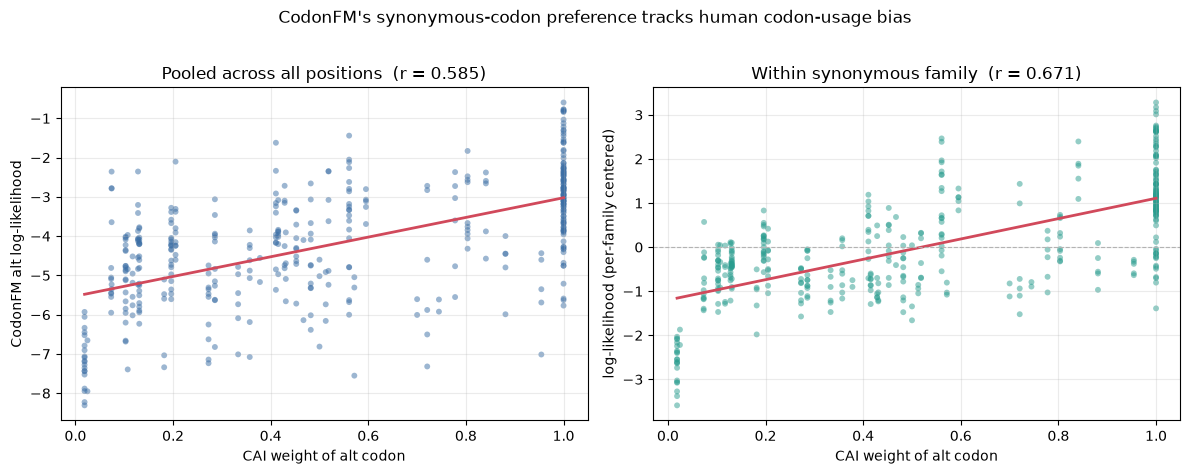

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

ax[0].scatter(xs, ys, s=18, alpha=0.5, color="#3b6ea5", edgecolor="none")
m, b = np.polyfit(xs, ys, 1)
xr = np.linspace(min(xs), max(xs), 50)
ax[0].plot(xr, m * xr + b, color="#d1495b", lw=2)
ax[0].set(xlabel="CAI weight of alt codon", ylabel="CodonFM alt log-likelihood",
          title=f"Pooled across all positions  (r = {r_pool:.3f})")

ax[1].scatter(centered_w, centered_ll, s=18, alpha=0.5, color="#2a9d8f", edgecolor="none")
mc, bc = np.polyfit(centered_w, centered_ll, 1)
ax[1].plot(xr, mc * xr + bc, color="#d1495b", lw=2)
ax[1].axhline(0, color="0.7", lw=0.8, ls="--")
ax[1].set(xlabel="CAI weight of alt codon", ylabel="log-likelihood (per-family centered)",
          title=f"Within synonymous family  (r = {r_within:.3f})")

for a in ax:
    a.grid(alpha=0.25)
fig.suptitle("CodonFM's synonymous-codon preference tracks human codon-usage bias", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## Iterative CodonFM-guided optimization — one codon per round

Rather than a single greedy pass, we run **coordinate ascent**: each round we re-score every synonymous alternative *in the current sequence context*, apply the single best-improving swap, re-measure all metrics, and repeat until no synonymous swap improves the local codon log-likelihood. Because Encodon is bidirectional, each accepted swap shifts its neighbours' scores — so the optimizer keeps finding new moves over many rounds.

We wrap the whole loop in `ToolInstance.persist()` so the checkpoint is loaded **once** and every round reuses the warm GPU worker.

In [16]:
import logging
import os

from proto_tools.utils.tool_instance import ToolInstance

# The loop makes ~3 tool calls per round; silence the per-call spinners/logs so we get
# one clean progression line per round instead of ~100 stacked progress bars.
os.environ["PROTO_NO_SPINNER"] = "1"
logging.getLogger("proto_tools.utils.progress").setLevel(logging.WARNING)

MAX_ROUNDS = 60
EPS = 1e-4  # minimum local log-likelihood gain to accept a swap


def score_synonymous(cds):
    """Batched codonfm-score of every synonymous alternative for the current CDS."""
    cur = [cds[i : i + 3] for i in range(0, len(cds), 3)]
    muts, idx = [], []
    for pos, c in enumerate(cur, start=1):
        aa = STANDARD_GENETIC_CODE[c]
        if aa == "*" or len(SYNONYMS[aa]) == 1:
            continue
        for alt in SYNONYMS[aa]:
            if alt == c:
                continue
            muts.append({"sequence": cds, "codon_position": pos, "ref_codon": c, "alt_codon": alt})
            idx.append((pos, alt))
    res = run_codonfm_score(
        CodonFMScoreInput(mutations=muts),
        CodonFMScoreConfig(model_checkpoint=CHECKPOINT, device=DEVICE, batch_size=64),
    ).results
    return cur, idx, res


history = []
change_log = []            # (round, position, old_codon, new_codon, local_gain)
current = NATURAL_CDS

with ToolInstance.persist():                       # warm worker for the whole run
    row = measure(current); row.update(round=0, changed=0, gain=0.0); history.append(row)
    for rnd in range(1, MAX_ROUNDS + 1):
        cur, idx, res = score_synonymous(current)
        best = None                                # (gain, pos, alt)
        for (pos, alt), r in zip(idx, res):
            gain = r.alt_log_likelihood - r.ref_log_likelihood
            if gain > EPS and (best is None or gain > best[0]):
                best = (gain, pos, alt)
        if best is None:
            print(f"converged after {rnd - 1} rounds — no improving synonymous swap remains")
            break
        gain, pos, alt = best
        old = cur[pos - 1]
        cur[pos - 1] = alt
        current = "".join(cur)
        change_log.append((rnd, pos, old, alt, gain))
        row = measure(current); row.update(round=rnd, changed=len(change_log), gain=gain); history.append(row)
        print(f"round {rnd:>2}: codon {pos:>3}  {old}->{alt}  local gain {gain:+.3f}  "
              f"fitness {row['fitness']:.4f}  CAI {row['CAI']:.3f}  MFE {row['MFE']:.1f}")

OPTIMIZED_CDS = current
assert translate(OPTIMIZED_CDS) == PROTEIN         # synonymous only -> identical protein
print(f"\ndone: {len(change_log)} codons changed over {history[-1]['round']} rounds; protein preserved.")

round  1: codon  41  CTA->CTG  local gain +3.408  fitness -0.7400  CAI 0.740  MFE -150.4


round  2: codon  94  CAA->CAG  local gain +2.436  fitness -0.7285  CAI 0.758  MFE -150.4


round  3: codon  96  TGT->TGC  local gain +2.542  fitness -0.7246  CAI 0.764  MFE -153.4


round  4: codon  93  GAA->GAG  local gain +2.505  fitness -0.7177  CAI 0.771  MFE -153.7


round  5: codon  28  CAA->CAG  local gain +2.641  fitness -0.7083  CAI 0.790  MFE -153.4


...

round 32: codon  31  TGC->TGT  local gain +0.170  fitness -0.6048  CAI 0.911  MFE -175.8


round 33: codon  21  CCA->CCT  local gain +0.007  fitness -0.6062  CAI 0.915  MFE -171.2


round 34: codon  33  AGC->TCC  local gain +0.018  fitness -0.6079  CAI 0.916  MFE -171.2


converged after 34 rounds — no improving synonymous swap remains



done: 34 codons changed over 34 rounds; protein preserved.


## Progression of every metric across the rounds

Each accepted swap is one point. CodonFM fitness (the objective) rises monotonically; CAI rises and MFE falls **with it**, unprompted — the correlation from above, now playing out over the trajectory.

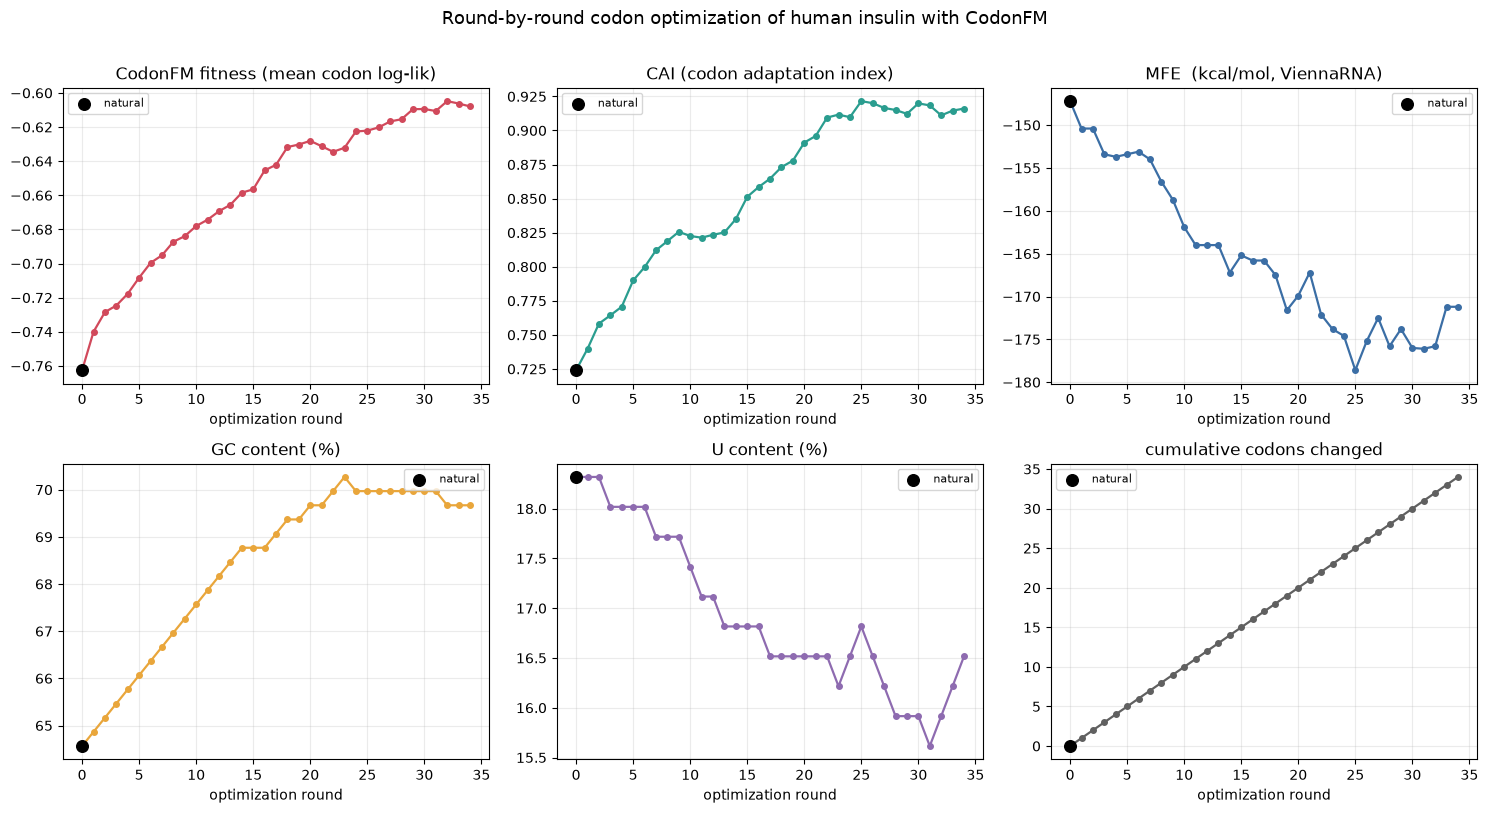

In [17]:
rounds = np.array([h["round"] for h in history])
series = {k: np.array([h[k] for h in history]) for k in ("fitness", "CAI", "MFE", "GC%", "U%", "changed")}
titles = {
    "fitness": "CodonFM fitness (mean codon log-lik)",
    "CAI": "CAI (codon adaptation index)",
    "MFE": "MFE  (kcal/mol, ViennaRNA)",
    "GC%": "GC content (%)",
    "U%": "U content (%)",
    "changed": "cumulative codons changed",
}
colors = {"fitness": "#d1495b", "CAI": "#2a9d8f", "MFE": "#3b6ea5",
          "GC%": "#e9a63b", "U%": "#8e6bb0", "changed": "#606060"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, key in zip(axes.ravel(), titles):
    ax.plot(rounds, series[key], marker="o", ms=4, lw=1.6, color=colors[key])
    ax.scatter([0], [series[key][0]], s=70, color="black", zorder=5, label="natural")
    ax.set(title=titles[key], xlabel="optimization round")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8)
fig.suptitle("Round-by-round codon optimization of human insulin with CodonFM", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## CAI and MFE co-improve with CodonFM fitness

Plotting the trajectory in the (fitness, metric) plane: each point is a round, colour runs early → late. As we climb in CodonFM fitness we drift toward **higher CAI** and **more negative MFE** — the design objectives move together.

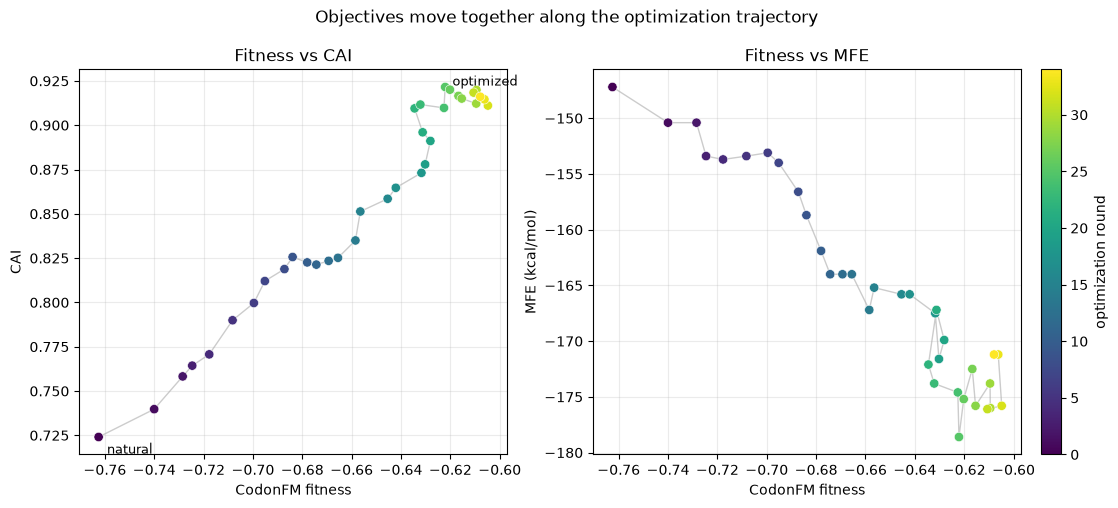

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc_kw = dict(c=rounds, cmap="viridis", s=45, zorder=3, edgecolor="white", linewidth=0.4)

ax[0].plot(series["fitness"], series["CAI"], color="0.8", lw=1, zorder=1)
p0 = ax[0].scatter(series["fitness"], series["CAI"], **sc_kw)
ax[0].annotate("natural", (series["fitness"][0], series["CAI"][0]), textcoords="offset points",
               xytext=(6, -12), fontsize=9)
ax[0].annotate("optimized", (series["fitness"][-1], series["CAI"][-1]), textcoords="offset points",
               xytext=(-20, 8), fontsize=9)
ax[0].set(xlabel="CodonFM fitness", ylabel="CAI", title="Fitness vs CAI")

ax[1].plot(series["fitness"], series["MFE"], color="0.8", lw=1, zorder=1)
ax[1].scatter(series["fitness"], series["MFE"], **sc_kw)
ax[1].set(xlabel="CodonFM fitness", ylabel="MFE (kcal/mol)", title="Fitness vs MFE")

for a in ax:
    a.grid(alpha=0.25)
cb = fig.colorbar(p0, ax=ax, fraction=0.045, pad=0.02)
cb.set_label("optimization round")
fig.suptitle("Objectives move together along the optimization trajectory", y=1.0, fontsize=12)
plt.show()

## Convergence — per-round gain and where the codons changed

Left: the local log-likelihood gain accepted each round decays as the easy wins are used up (why the run terminates). Right: the positions along the CDS that were rewritten, coloured by the round they changed.

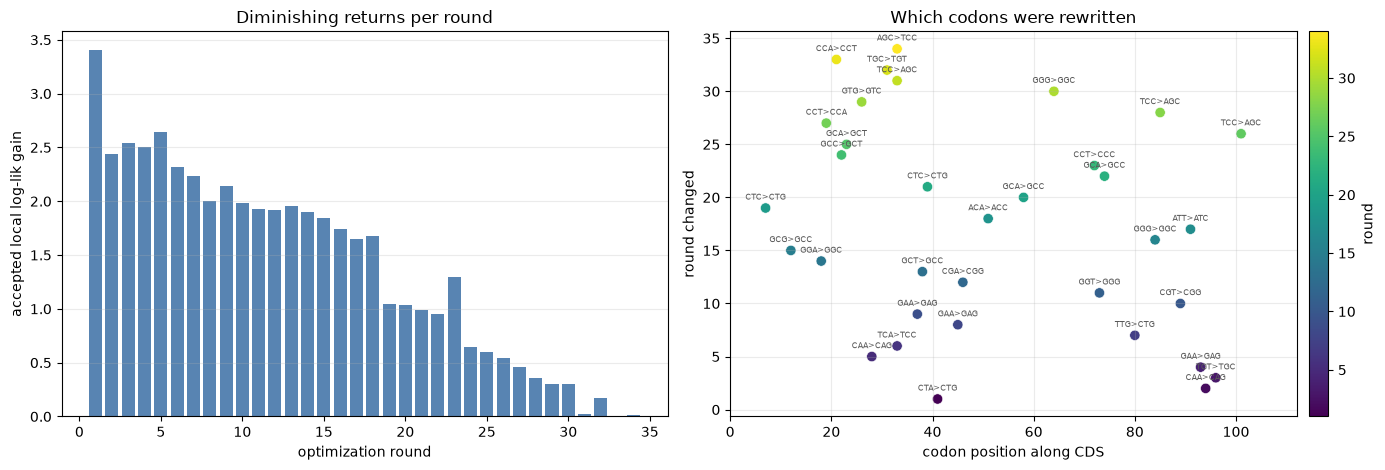

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

gains = np.array([h["gain"] for h in history[1:]])
gr = np.arange(1, len(gains) + 1)
ax[0].bar(gr, gains, color="#3b6ea5", alpha=0.85)
ax[0].set(xlabel="optimization round", ylabel="accepted local log-lik gain",
          title="Diminishing returns per round")
ax[0].grid(alpha=0.25, axis="y")

if change_log:
    rnd_arr = np.array([c[0] for c in change_log])
    pos_arr = np.array([c[1] for c in change_log])
    sc = ax[1].scatter(pos_arr, rnd_arr, c=rnd_arr, cmap="viridis", s=55, edgecolor="white", linewidth=0.4)
    for _r, _p, _o, _n, _g in change_log:
        ax[1].annotate(f"{_o}>{_n}", (_p, _r), textcoords="offset points", xytext=(0, 6),
                       ha="center", fontsize=6, color="0.35")
    ax[1].set(xlabel="codon position along CDS", ylabel="round changed",
              title="Which codons were rewritten", xlim=(0, len(codons) + 1))
    ax[1].grid(alpha=0.25)
    fig.colorbar(sc, ax=ax[1], fraction=0.045, pad=0.02, label="round")
fig.tight_layout()
plt.show()

## Before vs after — natural, then CodonFM-optimized

Same protein, rewritten codons. The optimizer pushed CodonFM fitness and CAI up and MFE down together.

metric        natural   optimized       delta
fitness        -0.763      -0.608      +0.155
CAI             0.724       0.916      +0.192
MFE          -147.200    -171.200     -24.000
GC%            64.565      69.670      +5.105
U%             18.318      16.517      -1.802

codons changed: 32/111   protein identical: True


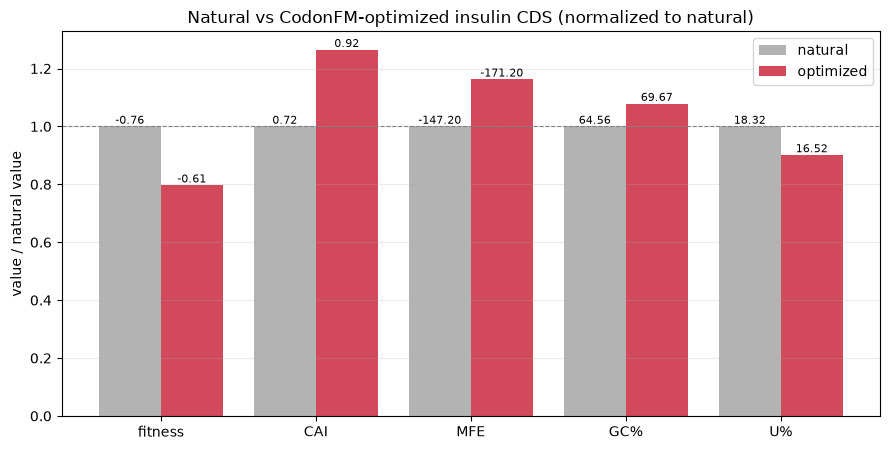

In [20]:
opt_metrics = {k: series[k][-1] for k in ("fitness", "CAI", "MFE", "GC%", "U%")}
print(f"{'metric':<9}{'natural':>12}{'optimized':>12}{'delta':>12}")
for k in ("fitness", "CAI", "MFE", "GC%", "U%"):
    d = opt_metrics[k] - natural_metrics[k]
    print(f"{k:<9}{natural_metrics[k]:>12.3f}{opt_metrics[k]:>12.3f}{d:>+12.3f}")
n_changed = sum(a != b for a, b in zip(codons, [OPTIMIZED_CDS[i:i+3] for i in range(0, len(OPTIMIZED_CDS), 3)]))
print(f"\ncodons changed: {n_changed}/{len(codons)}   protein identical: {translate(OPTIMIZED_CDS) == PROTEIN}")

# normalized grouped bar (each metric scaled to its natural value so they share an axis)
keys = ["fitness", "CAI", "MFE", "GC%", "U%"]
nat = np.array([natural_metrics[k] for k in keys])
opt = np.array([opt_metrics[k] for k in keys])
norm_nat = np.ones(len(keys))
norm_opt = opt / nat
x = np.arange(len(keys))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(x - 0.2, norm_nat, 0.4, label="natural", color="0.7")
ax.bar(x + 0.2, norm_opt, 0.4, label="optimized", color="#d1495b")
ax.axhline(1.0, color="0.5", lw=0.8, ls="--")
for xi, (n, o) in enumerate(zip(nat, opt)):
    ax.annotate(f"{n:.2f}", (xi - 0.2, 1.0), ha="center", va="bottom", fontsize=8)
    ax.annotate(f"{o:.2f}", (xi + 0.2, o / n), ha="center", va="bottom", fontsize=8)
ax.set(xticks=x, xticklabels=keys, ylabel="value / natural value",
       title="Natural vs CodonFM-optimized insulin CDS (normalized to natural)")
ax.legend()
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

---
**Takeaway.** CodonFM's masked codon likelihood is not an independent objective bolted onto CAI/MFE — it has *learned* human codon-usage bias (the correlation plots), so optimizing it round-by-round drags CAI up and MFE down for free. The bidirectional context is what makes the iterative, re-scored loop worthwhile: each swap reshapes the landscape for the next.